<a href="https://colab.research.google.com/github/somadinakunegbu-star/ai-network-anomaly-detection/blob/main/AI_Powered_Network_Anomaly_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd

# These are the column names for the NSL-KDD dataset
# (the file itself doesn't include headers, so we have to tell pandas what they are)
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

# This loads the training data directly from a public GitHub link
url = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt"
df = pd.read_csv(url, names=columns)

# Let's just look at the first 5 rows to see what we're working with
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [3]:
# How many rows and columns do we have?
print("Shape of the data:", df.shape)

# What are the unique values in the 'label' column?
print("\nDifferent types of traffic in this dataset:")
print(df['label'].value_counts())

Shape of the data: (125973, 43)

Different types of traffic in this dataset:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [4]:
# Let's look at which columns are text (not numbers)
print("Text columns:", df.select_dtypes(include='object').columns.tolist())

Text columns: ['protocol_type', 'service', 'flag', 'label']


In [11]:
df_encoded = pd.get_dummies(df, columns=['protocol_type', 'service', 'flag'])
print("New shape after encoding:", df_encoded.shape)

New shape after encoding: (125973, 124)


In [12]:
from sklearn.preprocessing import StandardScaler

# Separate out the label column (we don't want to scale this — it's text, not a feature)
labels = df_encoded['label']
features = df_encoded.drop('label', axis=1)

# Create the scaler and apply it to all our features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("Scaled features shape:", features_scaled.shape)
print("\nFirst row, before vs after scaling:")
print("Before:", features.iloc[0].values[:5])
print("After: ", features_scaled[0][:5])

Scaled features shape: (125973, 123)

First row, before vs after scaling:
Before: [np.int64(0) np.int64(491) np.int64(0) np.int64(0) np.int64(0)]
After:  [-0.11024922 -0.0076786  -0.00491864 -0.01408881 -0.08948642]


In [13]:
import numpy as np

# Convert labels to a simple binary: is it 'normal' or not?
is_normal = (labels == 'normal')

# Training data = ONLY normal traffic
X_train = features_scaled[is_normal.values]

# Test data = everything (normal + all attack types), so we can check performance later
X_test = features_scaled
y_test = is_normal.values  # True = normal, False = attack

print("Training set shape (normal only):", X_train.shape)
print("Test set shape (everything):", X_test.shape)
print("Number of normal rows in test set:", y_test.sum())
print("Number of attack rows in test set:", (~y_test).sum())

Training set shape (normal only): (67343, 123)
Test set shape (everything): (125973, 123)
Number of normal rows in test set: 67343
Number of attack rows in test set: 58630


In [14]:
from tensorflow import keras
from tensorflow.keras import layers

# How many features does each connection have? (this becomes our input size)
input_dim = X_train.shape[1]
print("Input dimension:", input_dim)

Input dimension: 123


In [15]:
# Build the autoencoder architecture
autoencoder = keras.Sequential([
    # Encoder - compressing down
    layers.Dense(64, activation='relu', input_shape=(input_dim,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),  # <-- this is our bottleneck

    # Decoder - expanding back up
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(input_dim, activation='linear')  # output same size as input
])

# Let's see a summary of the architecture we just built
autoencoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 123)            │         7,995 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,195 (82.79 KB)

 Trainable params: 21,195 (82.79 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
autoencoder.compile(optimizer='adam', loss='mse')
print("Model compiled and ready to train!")


Model compiled and ready to train!


In [17]:
history = autoencoder.fit(
    X_train, X_train,          # input AND target are the same (that's the whole autoencoder trick!)
    epochs=20,
    batch_size=32,
    validation_split=0.1,      # hold back 10% of training data to check progress
    verbose=1
)

Epoch 1/20
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.2687 - val_loss: 0.1391
Epoch 2/20
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1772 - val_loss: 0.0934
Epoch 3/20
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1432 - val_loss: 0.0925
Epoch 4/20
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1336 - val_loss: 0.0731
Epoch 5/20
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1190 - val_loss: 0.0705
Epoch 6/20
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1218 - val_loss: 0.0634
Epoch 7/20
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0995 - val_loss: 0.0652
Epoch 8/20
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0839 - val_loss: 0.0575
Epoch 9/20
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0831 - val_loss: 0.0553
Epoch 10/20
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0882 - val_loss: 0.0435
Epoch 11/20
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0694 - val_loss: 0.0516
Epoch 12/20
1894/1894 ━━━━━━━━

In [18]:
import numpy as np

# Run the test set through the autoencoder to get its reconstruction attempts
X_test_reconstructed = autoencoder.predict(X_test)

# Calculate reconstruction error for each row (Mean Squared Error per row)
reconstruction_errors = np.mean(np.square(X_test - X_test_reconstructed), axis=1)

# Let's compare: what's the average error for normal vs attack traffic?
normal_errors = reconstruction_errors[y_test]      # y_test True = normal
attack_errors = reconstruction_errors[~y_test]     # ~y_test = attack rows

print("Average reconstruction error for NORMAL traffic:", normal_errors.mean())
print("Average reconstruction error for ATTACK traffic:", attack_errors.mean())

3937/3937 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Average reconstruction error for NORMAL traffic: 0.04174021576296492
Average reconstruction error for ATTACK traffic: 1.597269462898044


In [19]:
# Set the threshold using the 95th percentile of NORMAL traffic's error
# (meaning: 95% of normal traffic falls below this error naturally)
threshold = np.percentile(normal_errors, 95)
print("Threshold set at:", threshold)

# Now classify every row in the test set: is its error above the threshold?
predicted_anomaly = reconstruction_errors > threshold

# Compare predictions to the real answer key (y_test: True = normal, False = attack)
actual_anomaly = ~y_test  # flip it, since True should mean "is an anomaly/attack"

# How many did we get right?
accuracy = (predicted_anomaly == actual_anomaly).mean()
print("Overall accuracy:", accuracy)

Threshold set at: 0.07350633772338411
Overall accuracy: 0.9634207330142174


In [20]:
from sklearn.metrics import classification_report, confusion_matrix

# classification_report gives us precision, recall, f1-score all at once
print("Classification Report:")
print(classification_report(actual_anomaly, predicted_anomaly, target_names=['Normal', 'Attack']))

# Confusion matrix shows exactly where we got things right vs wrong
cm = confusion_matrix(actual_anomaly, predicted_anomaly)
print("\nConfusion Matrix:")
print(cm)
print("\n(Format: rows = actual, columns = predicted)")
print("[[True Normal,  False Attack]")
print(" [False Normal, True Attack]]")

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.95      0.97     67343
      Attack       0.94      0.98      0.96     58630

    accuracy                           0.96    125973
   macro avg       0.96      0.96      0.96    125973
weighted avg       0.96      0.96      0.96    125973


Confusion Matrix:
[[63975  3368]
 [ 1240 57390]]

(Format: rows = actual, columns = predicted)
[[True Normal,  False Attack]
 [False Normal, True Attack]]


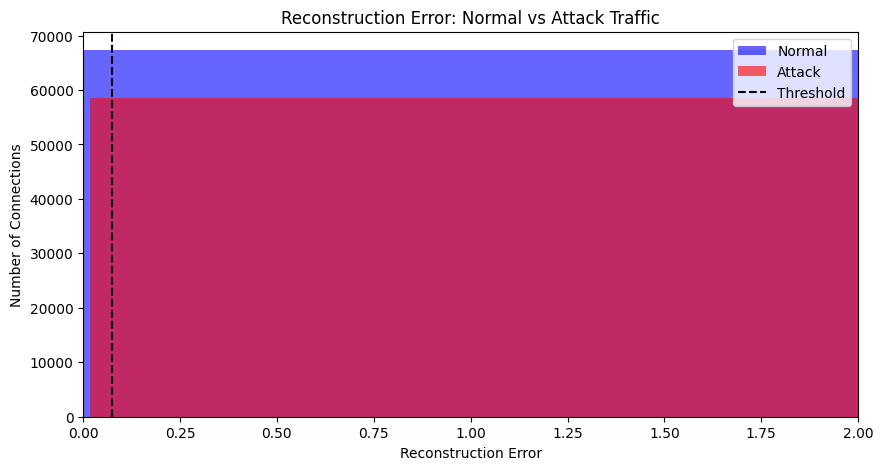

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(normal_errors, bins=50, alpha=0.6, label='Normal', color='blue')
plt.hist(attack_errors, bins=50, alpha=0.6, label='Attack', color='red')
plt.axvline(threshold, color='black', linestyle='--', label='Threshold')
plt.xlabel('Reconstruction Error')
plt.ylabel('Number of Connections')
plt.title('Reconstruction Error: Normal vs Attack Traffic')
plt.legend()
plt.xlim(0, 2)  # zoom in so the chart is readable
plt.show()

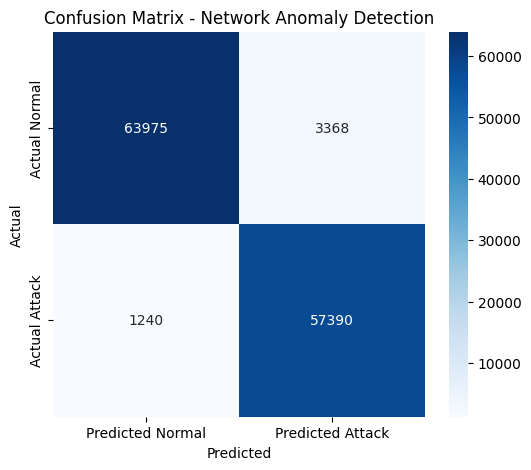

In [22]:
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Attack'],
            yticklabels=['Actual Normal', 'Actual Attack'])
plt.title('Confusion Matrix - Network Anomaly Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [23]:
import joblib

# Save the trained autoencoder model
autoencoder.save('autoencoder_model.keras')

# Save the scaler too (we'll need it to preprocess new incoming data the same way)
joblib.dump(scaler, 'scaler.pkl')

# Save the threshold value
joblib.dump(threshold, 'threshold.pkl')

print("Model, scaler, and threshold saved!")

Model, scaler, and threshold saved!
